In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.1 MB/s eta 0:00:00


In [2]:
from google.colab import files

# This will open a file picker to upload your zip
uploaded = files.upload()

Saving bangla-sign-language-model.v4i.yolov8.zip to bangla-sign-language-model.v4i.yolov8.zip


In [3]:
# unzip the dataset
!unzip bangla-sign-language-model.v4i.yolov8.zip -d dataset

Archive:  bangla-sign-language-model.v4i.yolov8.zip
  inflating: dataset/README.dataset.txt  
  inflating: dataset/README.roboflow.txt  
  inflating: dataset/data.yaml       
   creating: dataset/test/
   creating: dataset/test/images/
 extracting: dataset/test/images/IMG_20250623_140525_jpg.rf.481671542add3bea8d2995ef8adf5cfd.jpg  
 extracting: dataset/test/images/IMG_20250623_140556-2_jpg.rf.604c0a69b8194712093e1a04f894a26c.jpg  
 extracting: dataset/test/images/IMG_20250623_140754_jpg.rf.8812578ae9b99d60f329465564251435.jpg  
 extracting: dataset/test/images/IMG_20250623_141048_jpg.rf.6ee78cbc738f137d2a8749a8d0747b25.jpg  
 extracting: dataset/test/images/IMG_20250623_141828-2_jpg.rf.7ca9adaace8a4417532d702fecd3799d.jpg  
   creating: dataset/test/labels/
  inflating: dataset/test/labels/IMG_20250623_140525_jpg.rf.481671542add3bea8d2995ef8adf5cfd.txt  
  inflating: dataset/test/labels/IMG_20250623_140556-2_jpg.rf.604c0a69b8194712093e1a04f894a26c.txt  
  inflating: dataset/test/label

In [4]:
!ls

bangla-sign-language-model.v4i.yolov8.zip  dataset  sample_data


In [5]:
# Check main folders in dataset
!ls dataset

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [6]:
!ls dataset/train

images	labels


In [9]:
from ultralytics import YOLO

# Load YOLOv11 nano model (fast on Colab GPU)
model = YOLO("yolov8n.pt")

# Train the model
model.train(
    data="dataset/data.yaml",  # path to your YAML file
    epochs=50,                 # number of training epochs
    imgsz=640,                 # image size
    batch=16,                  # adjust if GPU runs out of memory
    device=0                    # use GPU
)

Ultralytics 8.3.191 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791d33392e40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [10]:
# validate the model
model.val()

Ultralytics 8.3.191 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 645.7±202.3 MB/s, size: 20.1 KB)
val: Scanning /content/dataset/valid/labels.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 64527.8it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         45         45      0.989      0.981      0.995      0.785
                     A         10         10          1      0.906      0.995      0.828
                     B          5          5      0.977          1      0.995      0.795
                     C          9          9      0.995          1      0.995       0.77
                     D         11         11      0.995          1      0.995      0.761
                     E         10         10      0.9

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x791d30057bf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [20]:
# Run predictions
results = model.predict(
    source="dataset/valid/images",
    conf=0.25,
    save=True,             # save annotated images
    project="runs/detect", # parent folder
    name="predict"         # fixed folder
)


image 1/45 /content/dataset/valid/images/IMG_20250623_140147-2_jpg.rf.49163141ba71e2ef89d77c04d52368ea.jpg: 640x640 1 A, 9.0ms
image 2/45 /content/dataset/valid/images/IMG_20250623_140156-2_jpg.rf.7fee704e9e33c740b933134d893cf203.jpg: 640x640 1 A, 11.9ms
image 3/45 /content/dataset/valid/images/IMG_20250623_140216-2_jpg.rf.90af07ba56b1222ccf55e049035fa801.jpg: 640x640 1 A, 7.3ms
image 4/45 /content/dataset/valid/images/IMG_20250623_140339-2_jpg.rf.0540d971c2e473f62252114a67df0fa7.jpg: 640x640 1 A, 7.2ms
image 5/45 /content/dataset/valid/images/IMG_20250623_140524-2_jpg.rf.cb9982a7a81f599415c84d81a139c847.jpg: 640x640 1 A, 1 E, 7.3ms
image 6/45 /content/dataset/valid/images/IMG_20250623_140538-2_jpg.rf.ba5759a110ba62a2dd6a0cf152328e5b.jpg: 640x640 1 A, 7.3ms
image 7/45 /content/dataset/valid/images/IMG_20250623_140549-2_jpg.rf.76ecee315ef0af28535790972fd133a9.jpg: 640x640 1 A, 7.2ms
image 8/45 /content/dataset/valid/images/IMG_20250623_140604_jpg.rf.22ddc4d62c60abcd22f042b3bf957984.jpg

In [21]:
!ls runs/detect

predict  train	train2	train3


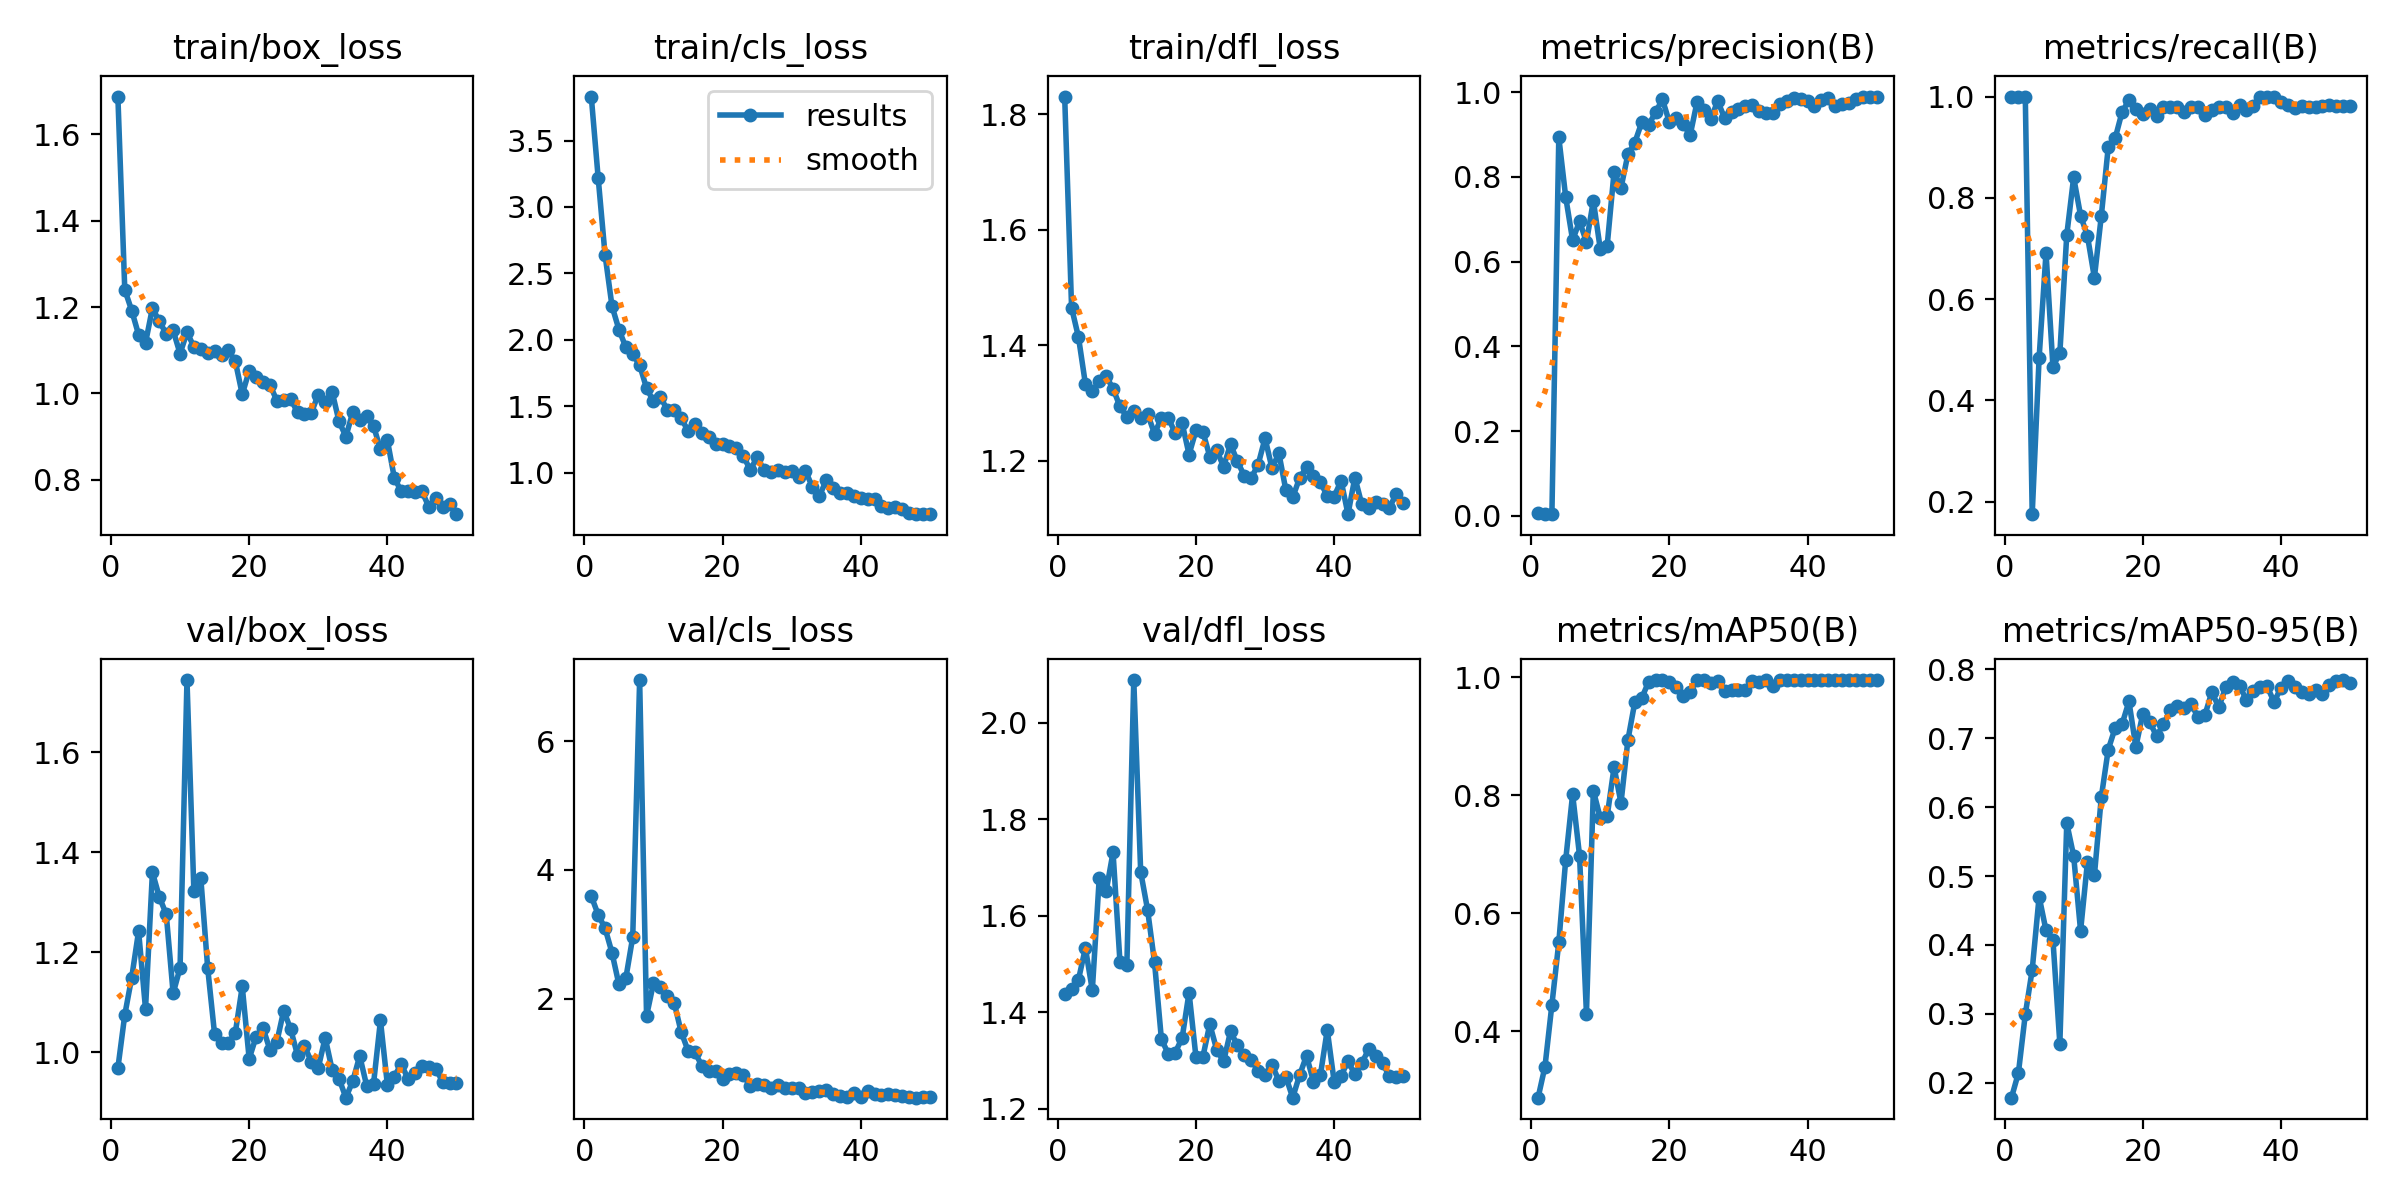

In [22]:
from IPython.display import Image, display

# Show training summary image
display(Image(filename='runs/detect/train/results.png'))

In [23]:
metrics = model.val()  # returns metrics dictionary
print(metrics)

Ultralytics 8.3.191 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 904.3±274.9 MB/s, size: 18.5 KB)
val: Scanning /content/dataset/valid/labels.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 103477.9it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.2it/s 1.3s
                   all         45         45      0.989      0.981      0.995      0.785
                     A         10         10          1      0.906      0.995      0.828
                     B          5          5      0.977          1      0.995      0.795
                     C          9          9      0.995          1      0.995       0.77
                     D         11         11      0.995          1      0.995      0.761
                     E         10         10      0.981          1      0.995      0.768
Speed: 3.3ms preprocess, 8.5ms inference, 0

In [24]:
results = model.predict(
    source="dataset/valid/images",
    conf=0.25
)


image 1/45 /content/dataset/valid/images/IMG_20250623_140147-2_jpg.rf.49163141ba71e2ef89d77c04d52368ea.jpg: 640x640 1 A, 8.1ms
image 2/45 /content/dataset/valid/images/IMG_20250623_140156-2_jpg.rf.7fee704e9e33c740b933134d893cf203.jpg: 640x640 1 A, 7.3ms
image 3/45 /content/dataset/valid/images/IMG_20250623_140216-2_jpg.rf.90af07ba56b1222ccf55e049035fa801.jpg: 640x640 1 A, 7.2ms
image 4/45 /content/dataset/valid/images/IMG_20250623_140339-2_jpg.rf.0540d971c2e473f62252114a67df0fa7.jpg: 640x640 1 A, 7.2ms
image 5/45 /content/dataset/valid/images/IMG_20250623_140524-2_jpg.rf.cb9982a7a81f599415c84d81a139c847.jpg: 640x640 1 A, 1 E, 7.3ms
image 6/45 /content/dataset/valid/images/IMG_20250623_140538-2_jpg.rf.ba5759a110ba62a2dd6a0cf152328e5b.jpg: 640x640 1 A, 7.3ms
image 7/45 /content/dataset/valid/images/IMG_20250623_140549-2_jpg.rf.76ecee315ef0af28535790972fd133a9.jpg: 640x640 1 A, 7.2ms
image 8/45 /content/dataset/valid/images/IMG_20250623_140604_jpg.rf.22ddc4d62c60abcd22f042b3bf957984.jpg:

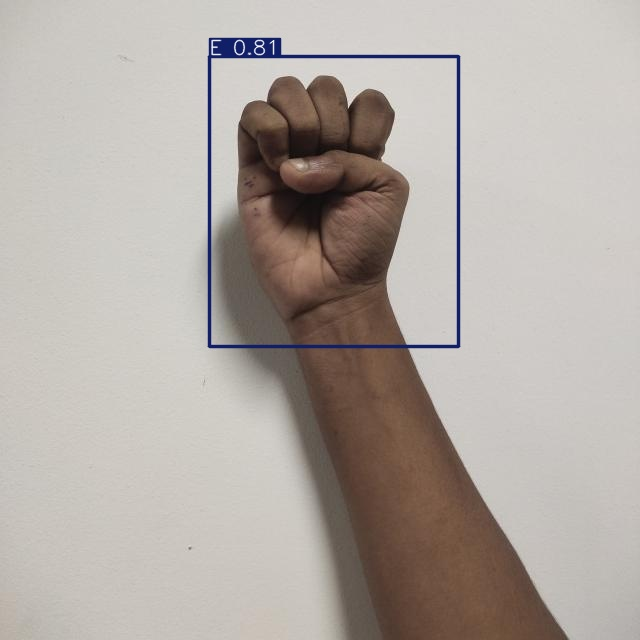

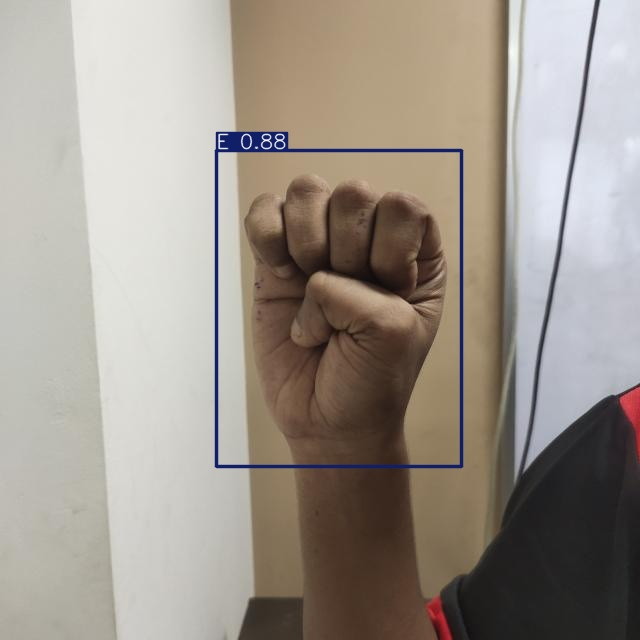

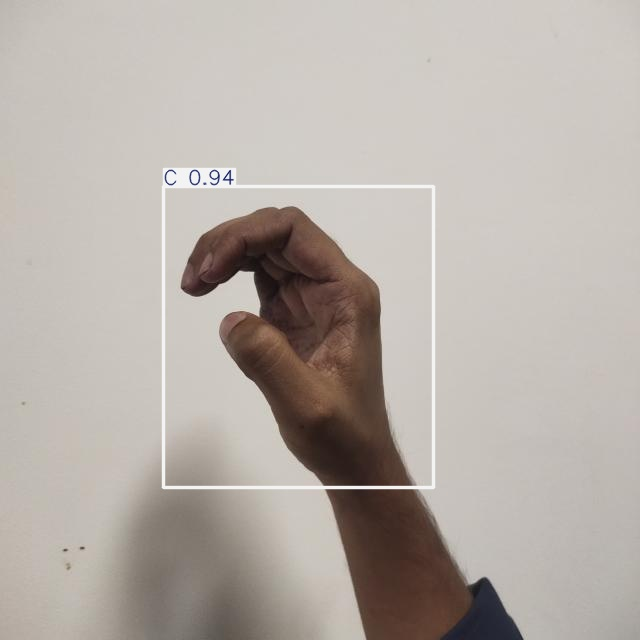

In [25]:
import os
from IPython.display import Image, display

pred_folder = "runs/detect/predict/"  # folder where YOLO saved predictions
images = os.listdir(pred_folder)[:3]  # first 3 images

for img in images:
    display(Image(filename=os.path.join(pred_folder, img)))


In [26]:
# Validate the trained model
metrics = model.val()  # returns a dictionary of metrics
print(metrics)

Ultralytics 8.3.191 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 936.9±147.2 MB/s, size: 22.7 KB)
val: Scanning /content/dataset/valid/labels.cache... 45 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 45/45 93114.8it/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.5s
                   all         45         45      0.989      0.981      0.995      0.785
                     A         10         10          1      0.906      0.995      0.828
                     B          5          5      0.977          1      0.995      0.795
                     C          9          9      0.995          1      0.995       0.77
                     D         11         11      0.995          1      0.995      0.761
                     E         10         10      0.981          1      0.995      0.768
Speed: 5.8ms preprocess, 6.0ms inference, 0.

In [29]:
!ls runs/detect/train/

args.yaml			 labels.jpg	     train_batch521.jpg
BoxF1_curve.png			 results.csv	     train_batch522.jpg
BoxP_curve.png			 results.png	     val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg    val_batch0_pred.jpg
BoxR_curve.png			 train_batch1.jpg    val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch2.jpg    val_batch1_pred.jpg
confusion_matrix.png		 train_batch520.jpg  weights


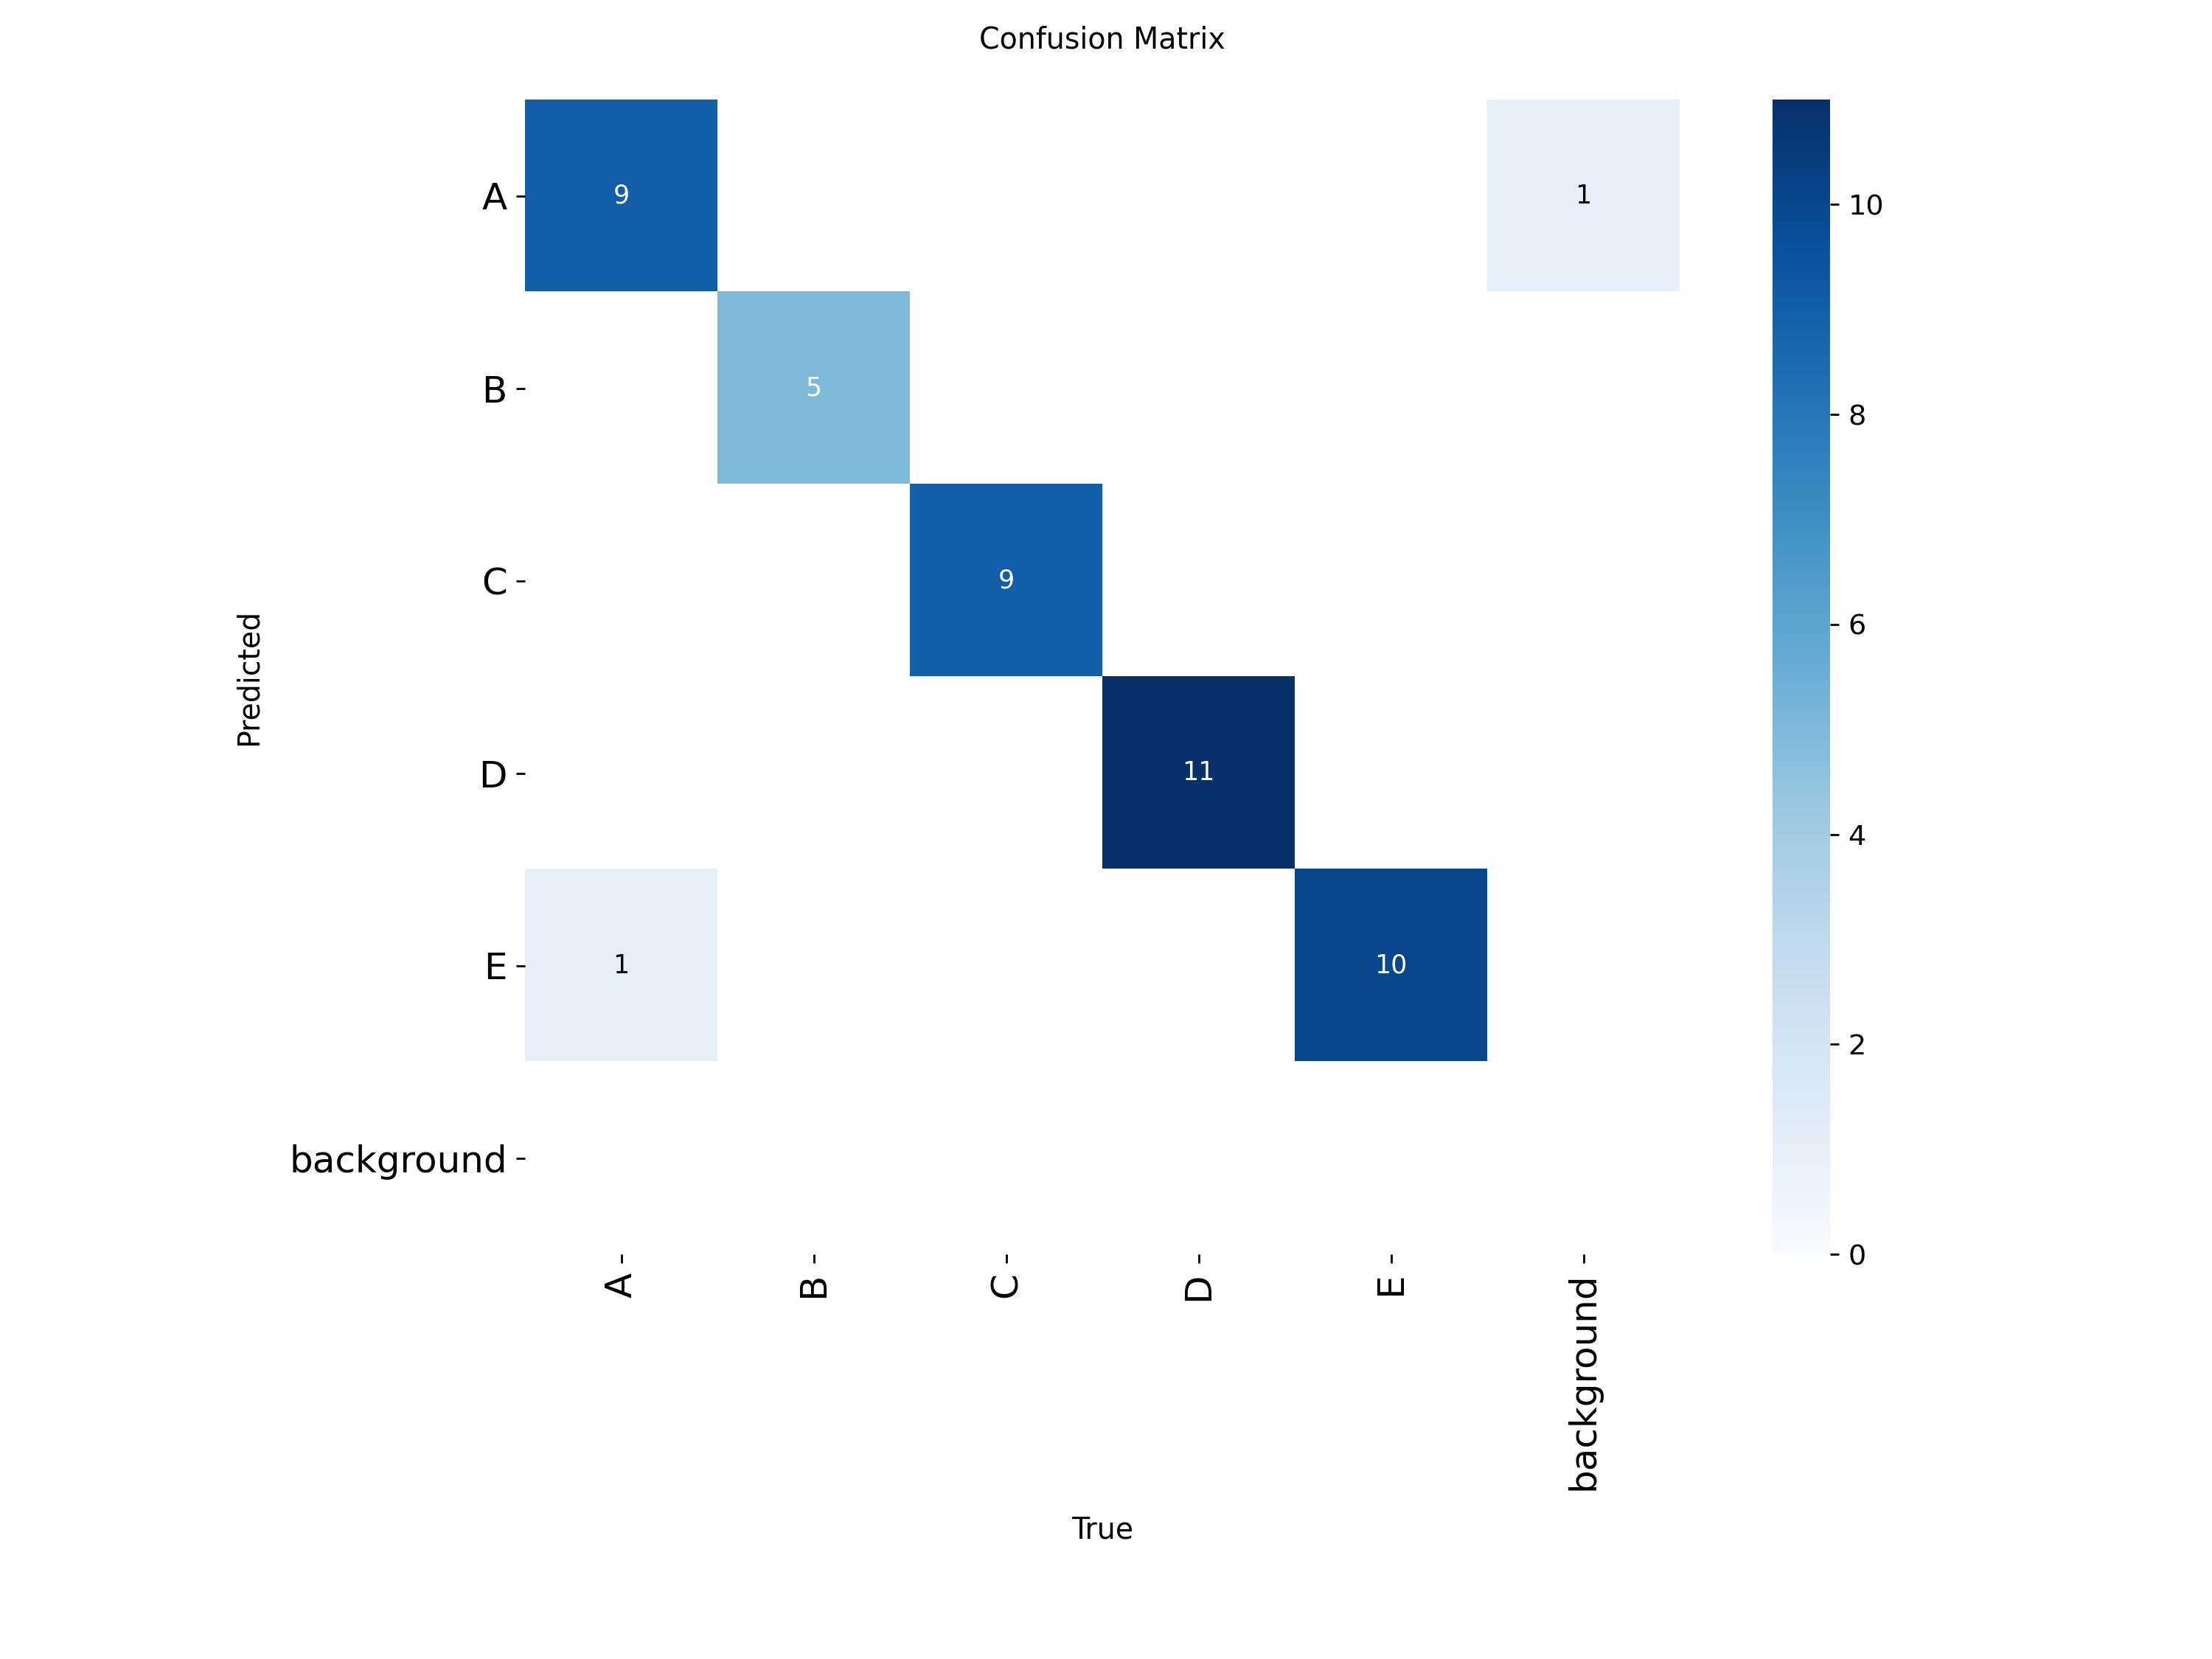

In [36]:
# Display the confusion matrix
display(Image(filename='runs/detect/train/confusion_matrix.png'))

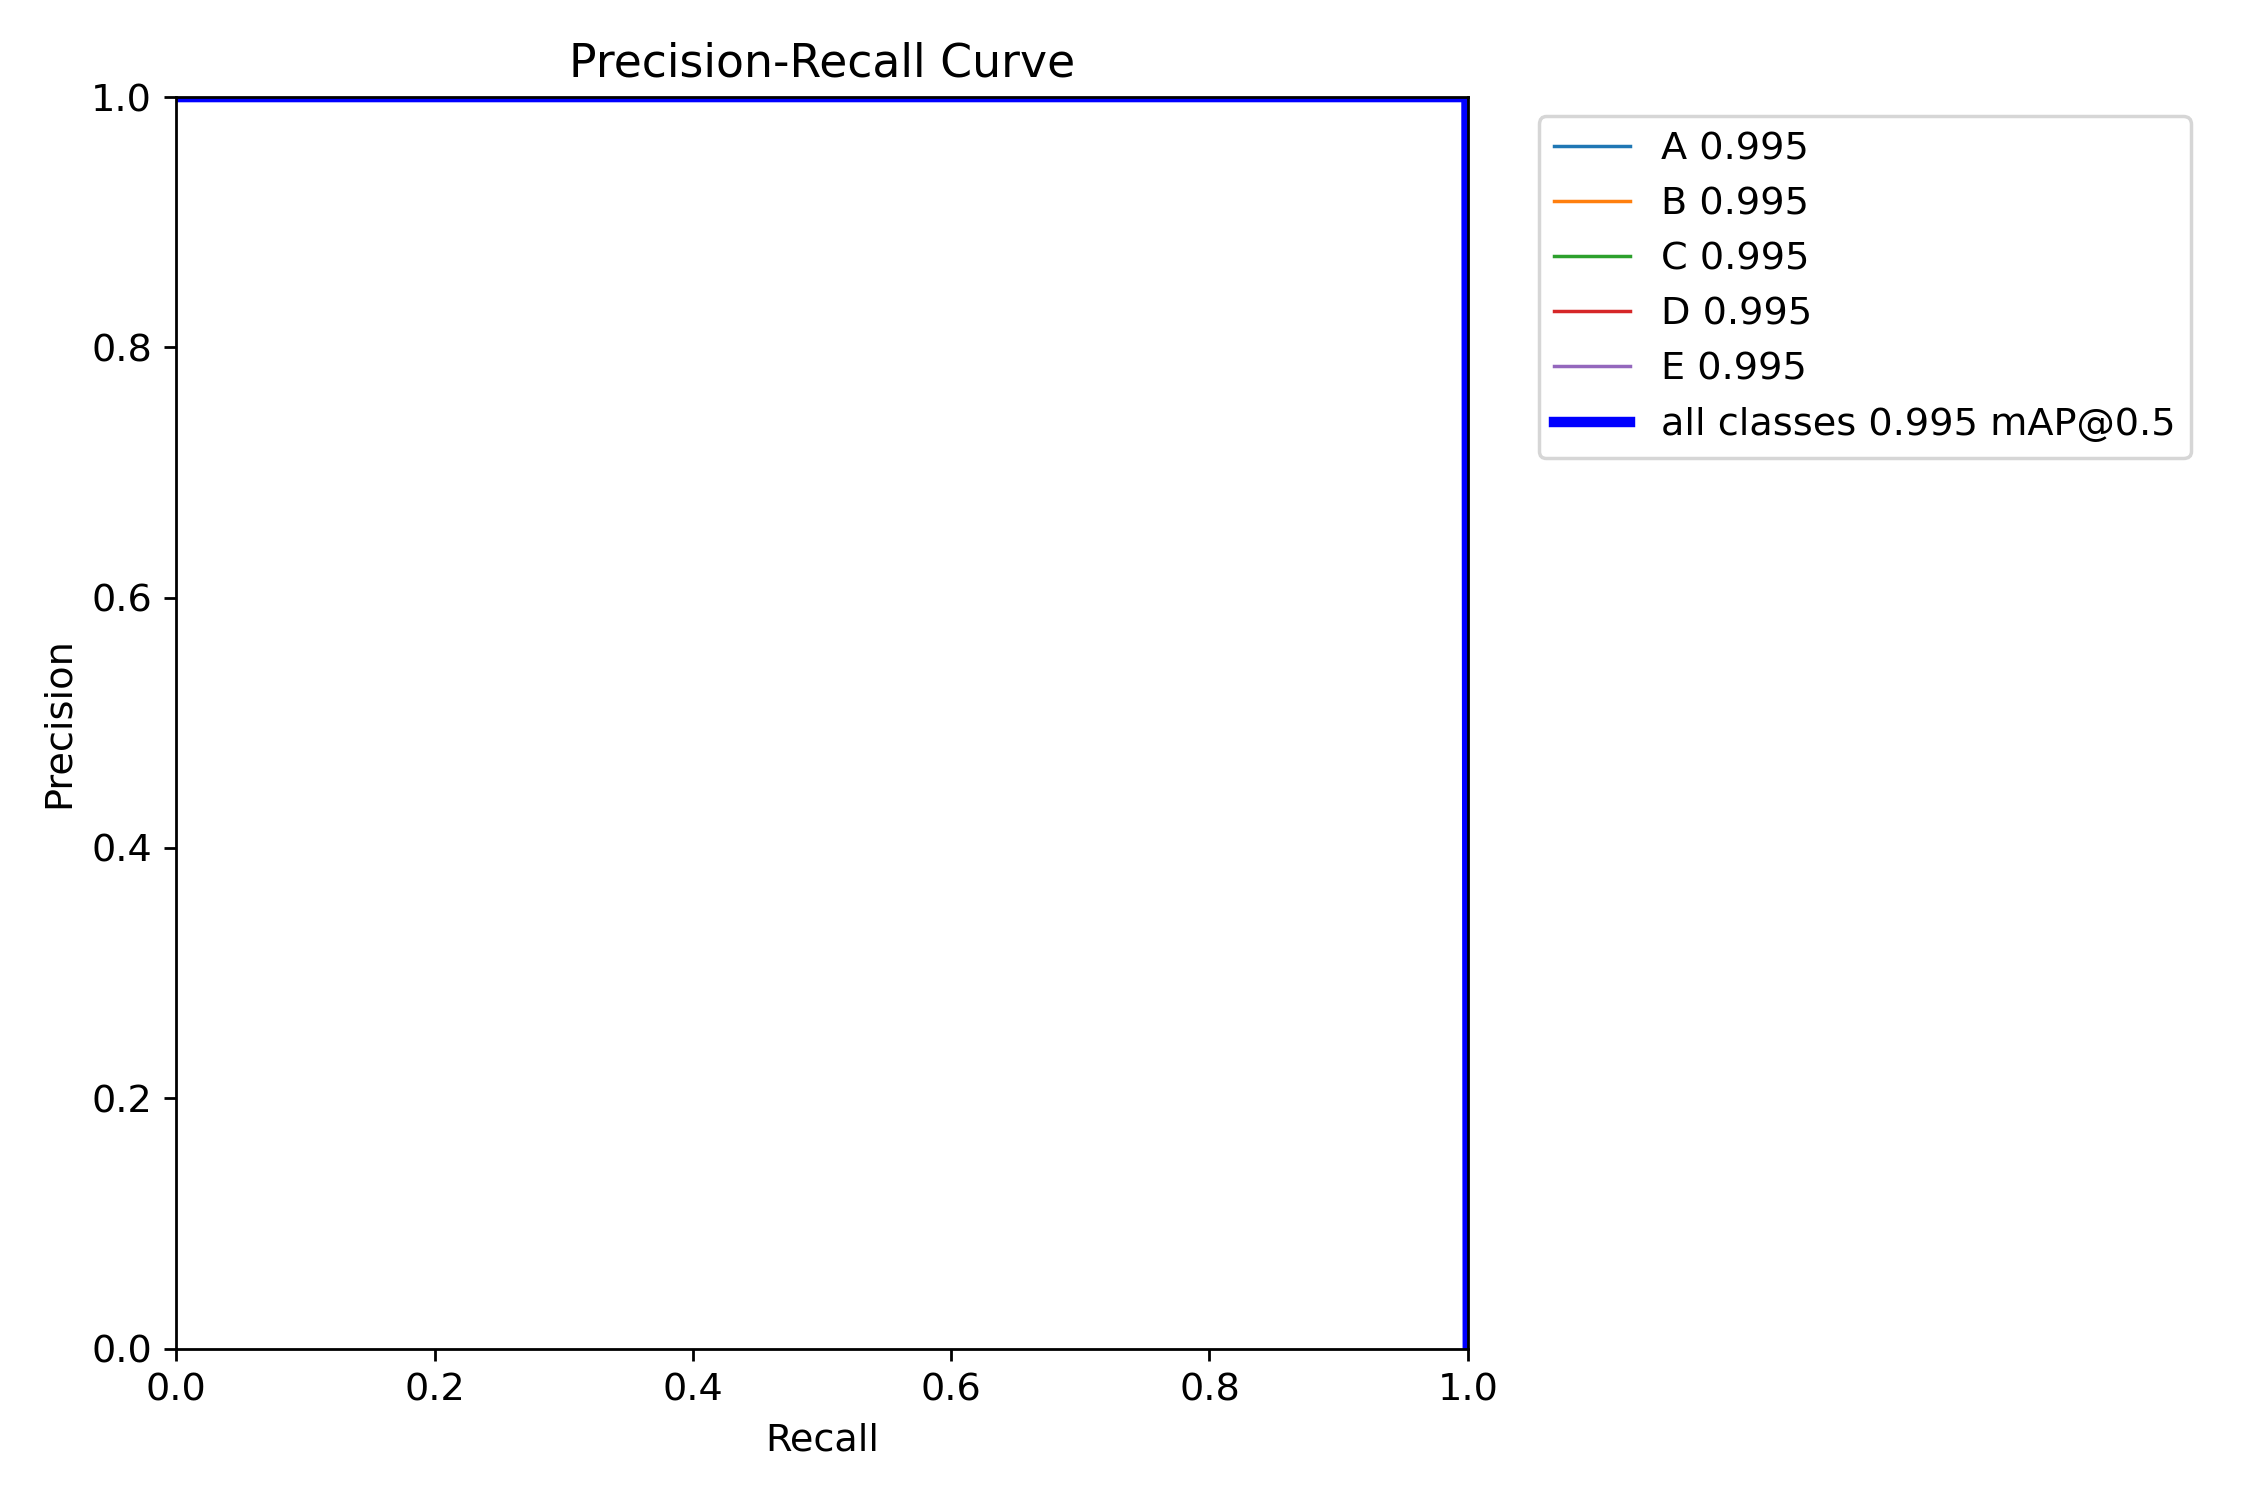

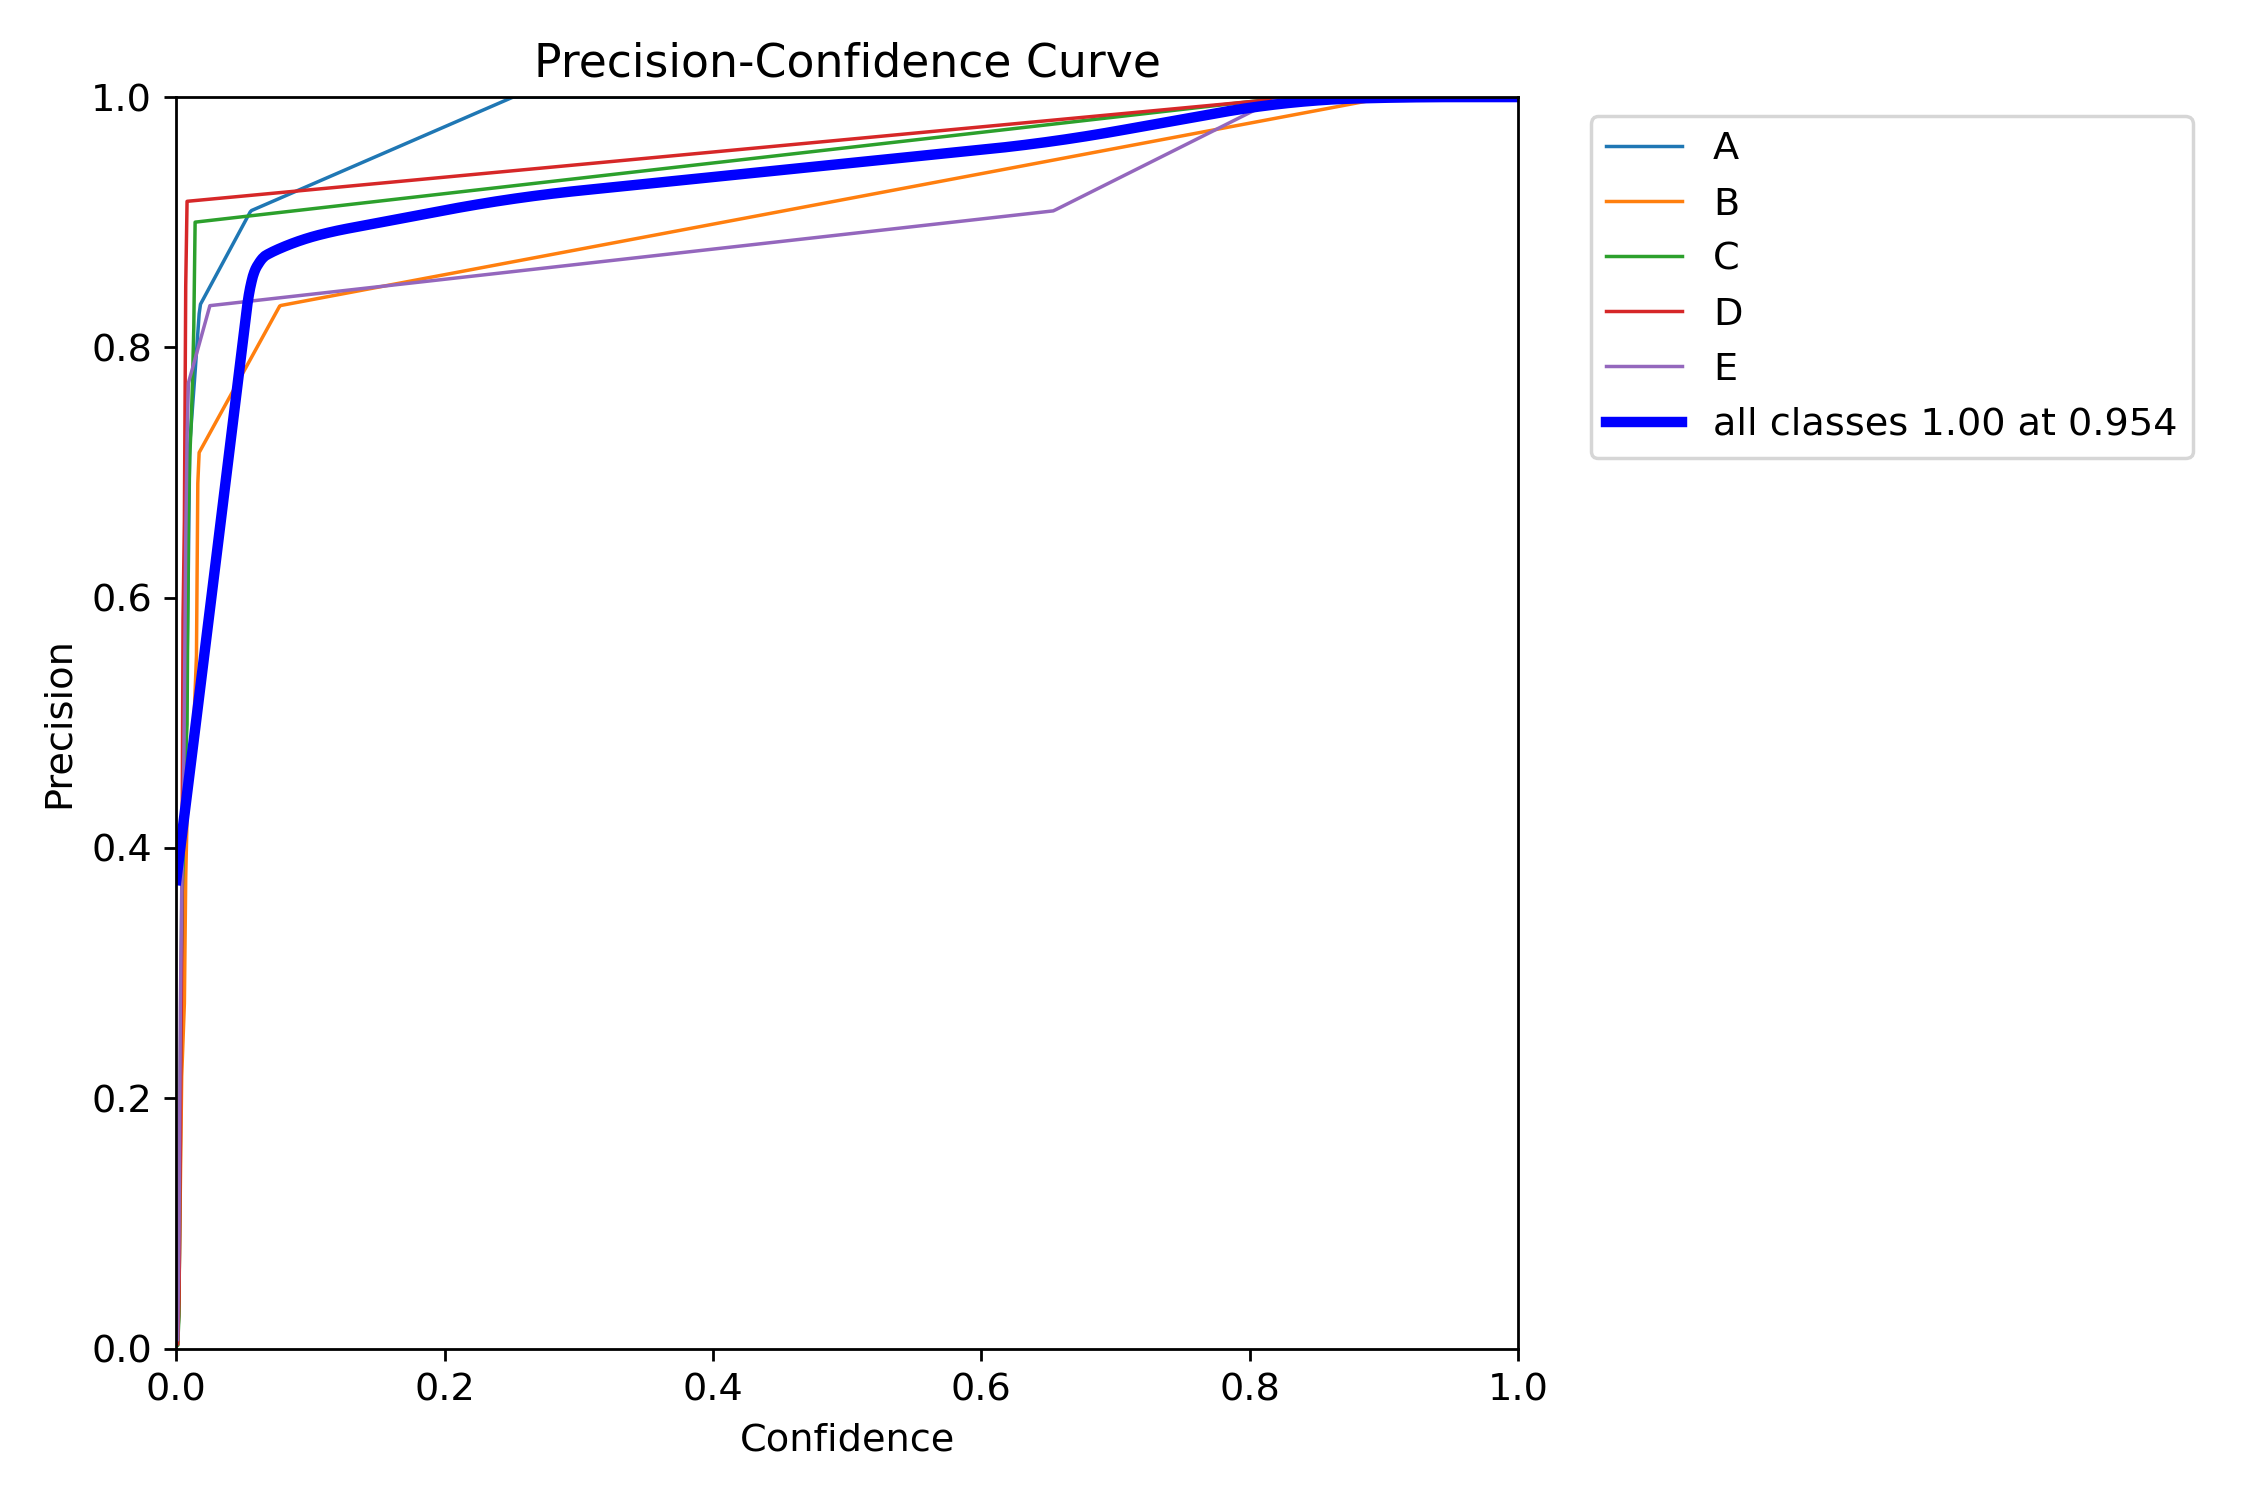

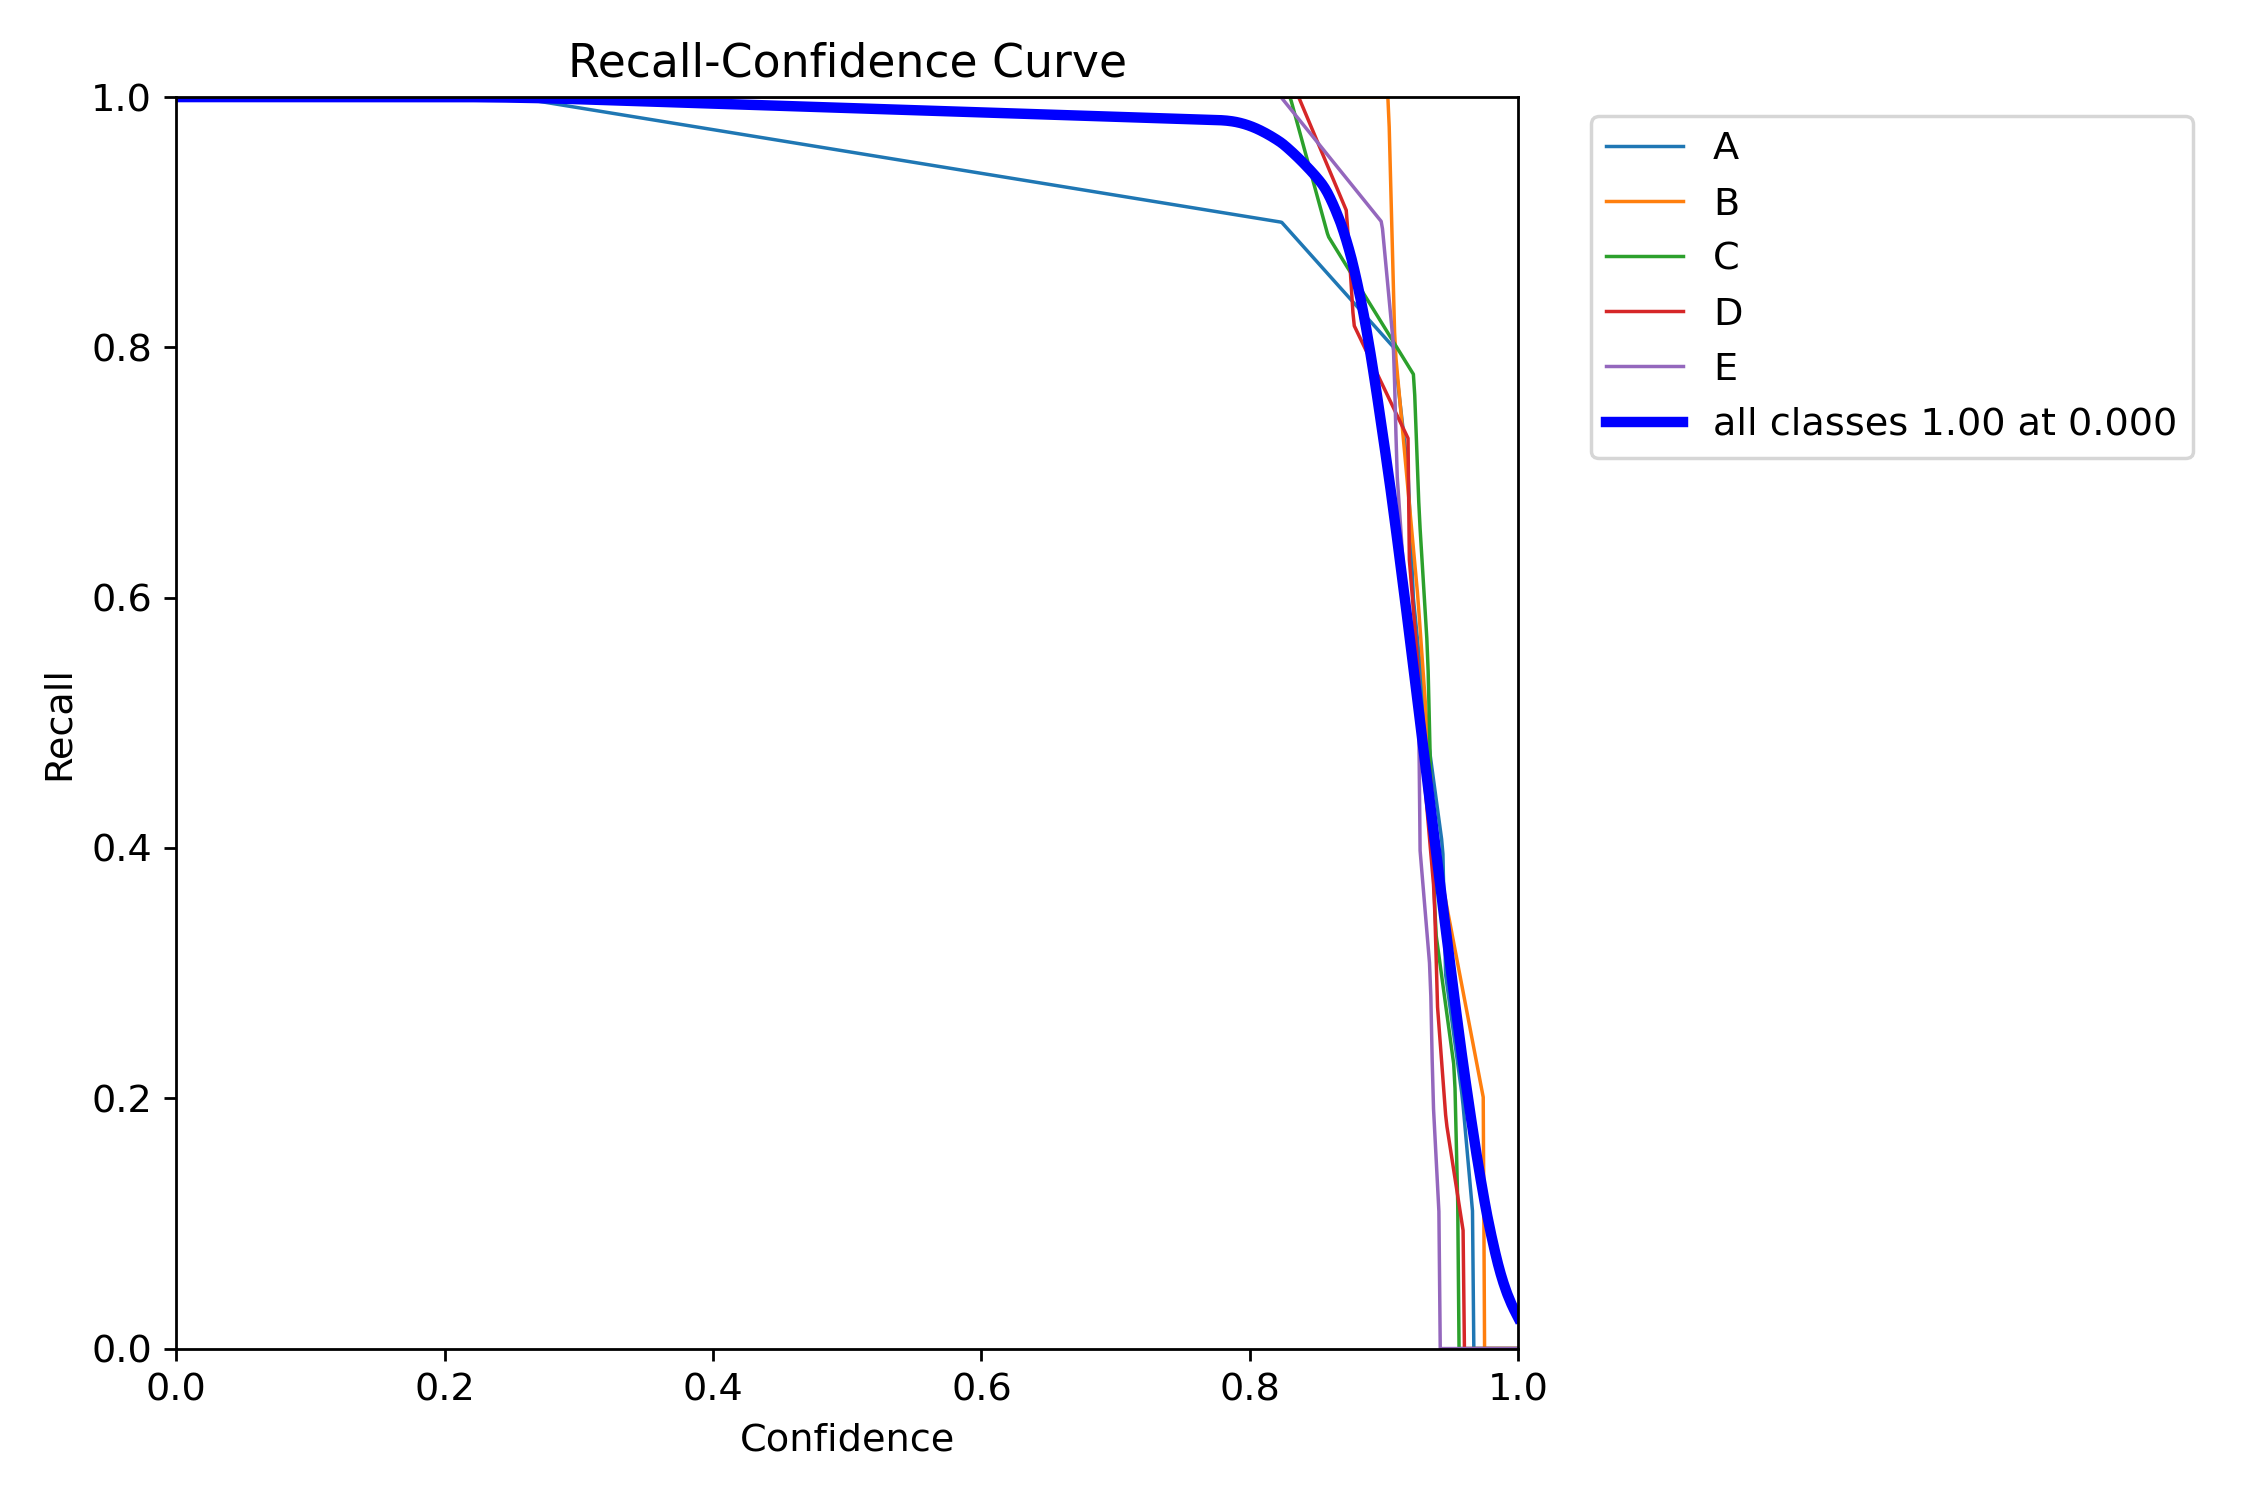

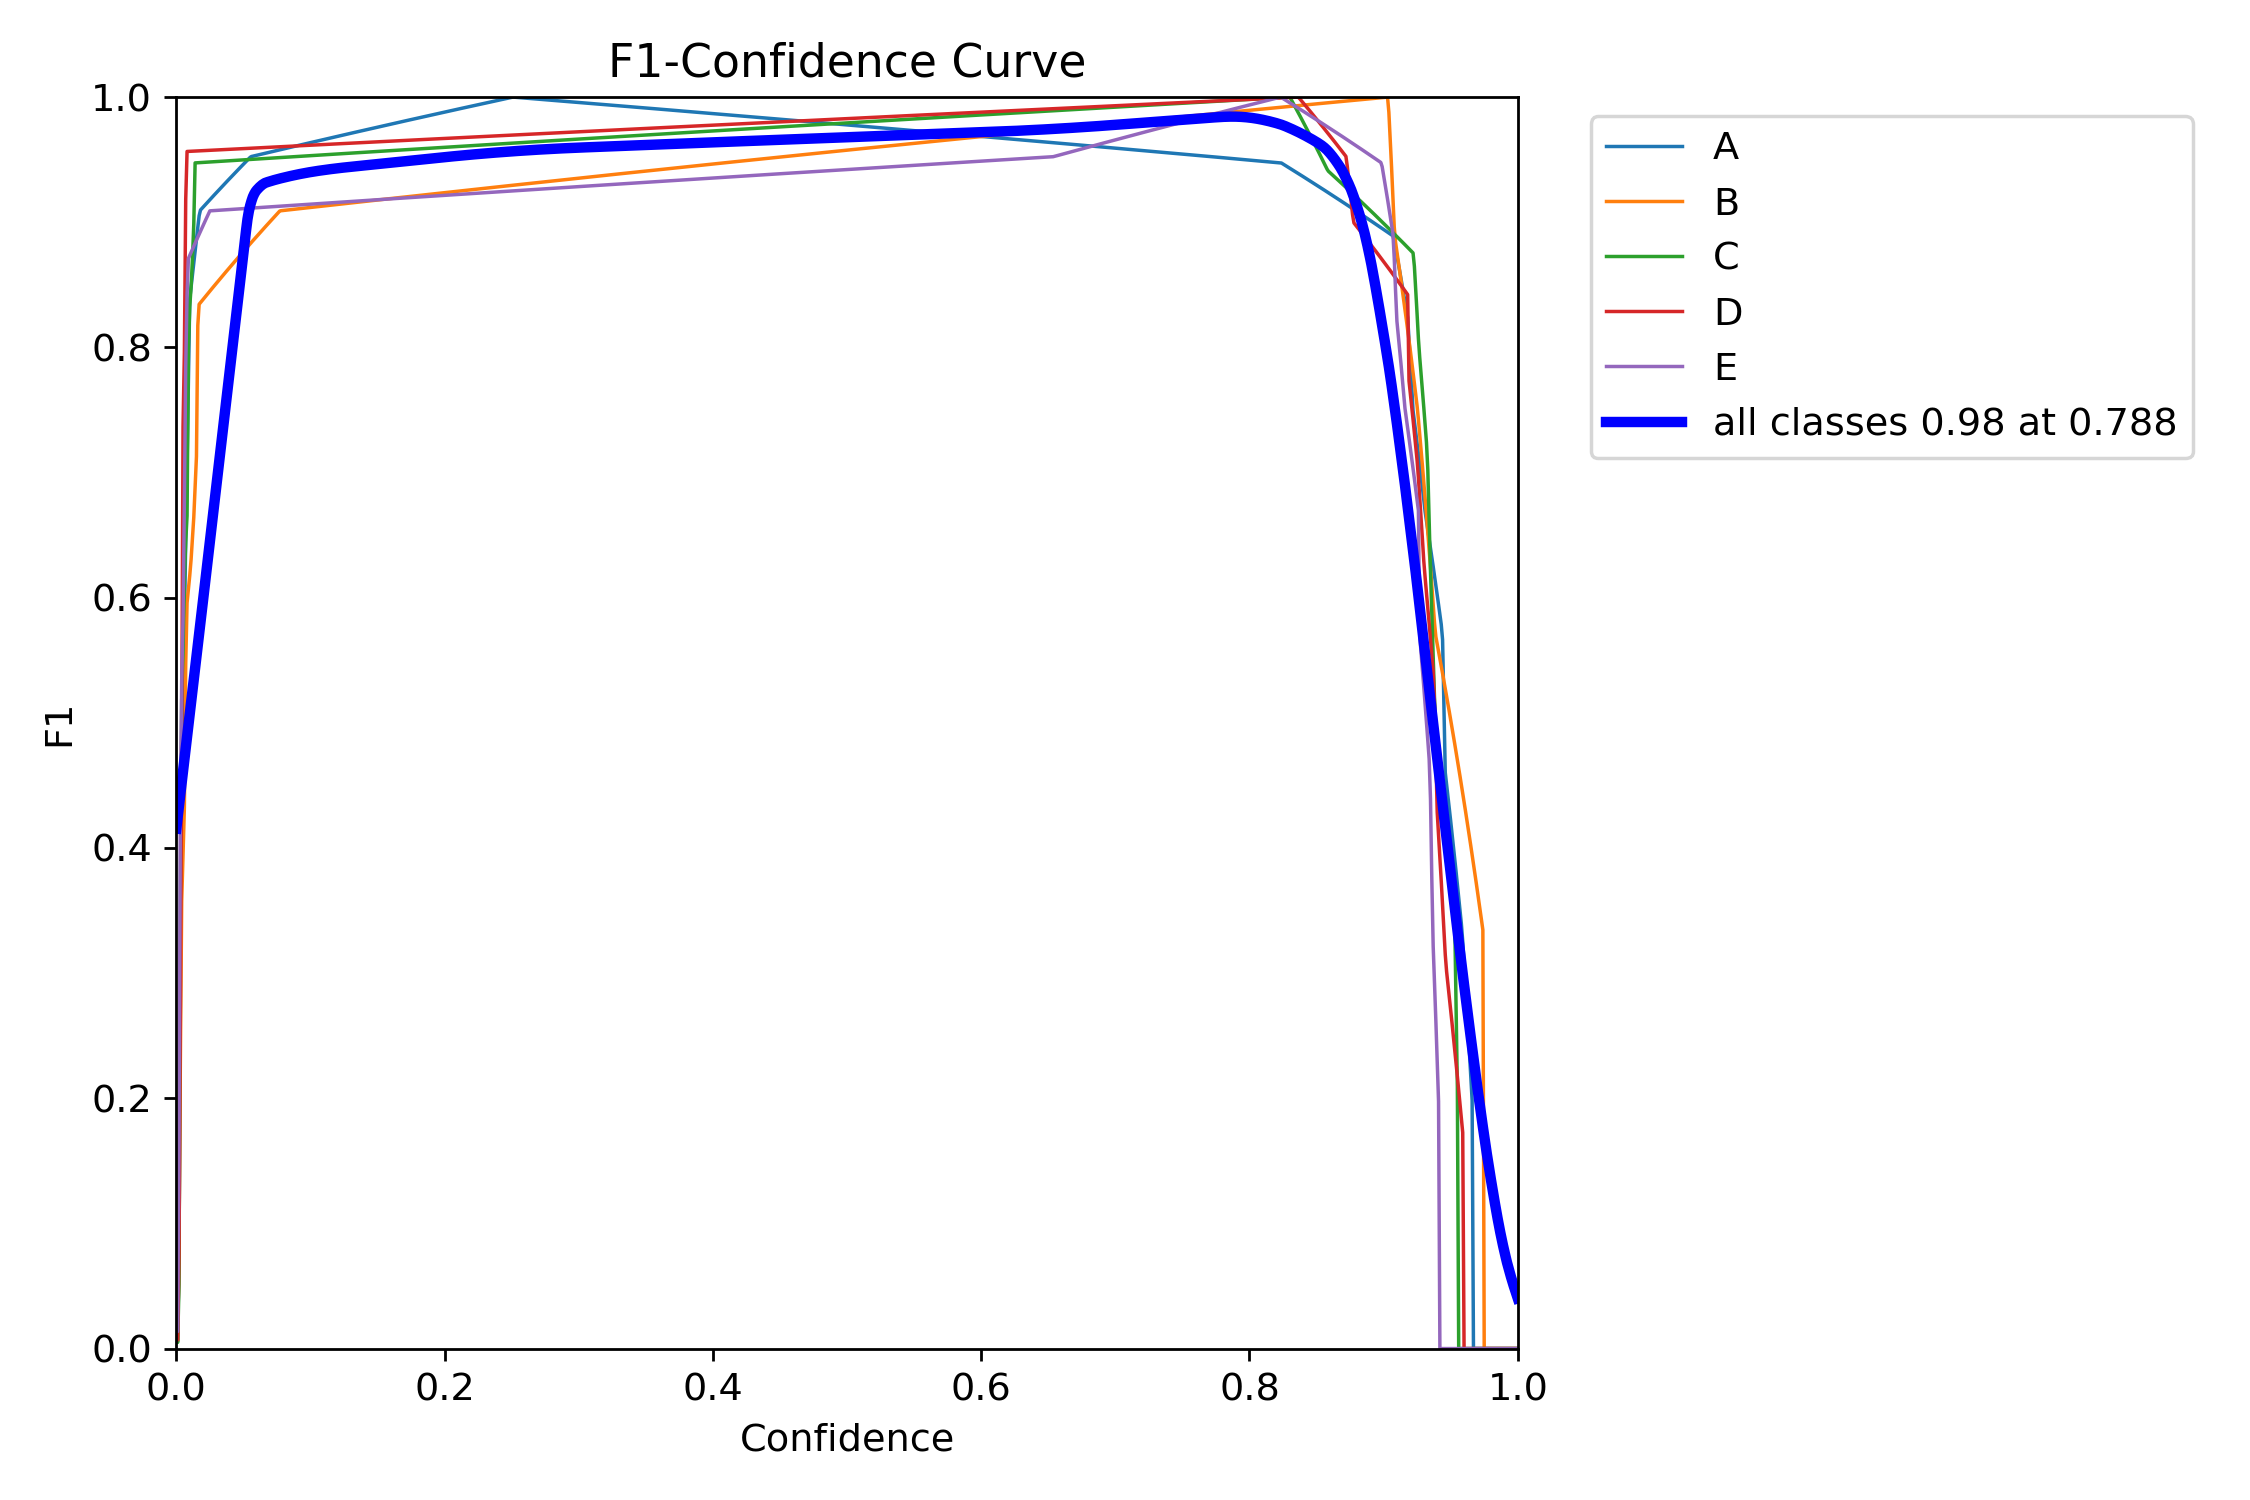

In [32]:
# Display Precision-Recall and other curves
display(Image(filename='runs/detect/train/BoxPR_curve.png'))   # Precision-Recall
display(Image(filename='runs/detect/train/BoxP_curve.png'))    # Precision
display(Image(filename='runs/detect/train/BoxR_curve.png'))    # Recall
display(Image(filename='runs/detect/train/BoxF1_curve.png'))   # F1-score